# Plot Lake Lucerne Bathymetry

In [181]:
import os
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from functionsEawag import *
import scipy.signal as sci
from matplotlib import cm, colors

# Bathy

In [167]:
fp='../data/bathymetry.nc'
bathy=xr.open_dataset(fp)

In [168]:
bathy

<xarray.Dataset> Size: 5GB
Dimensions:  (ysc: 21421, xsc: 26497)
Coordinates:
  * ysc      (ysc) int64 171kB 1193664 1193665 1193666 ... 1215083 1215084
  * xsc      (xsc) int64 212kB 2663921 2663922 2663923 ... 2690416 2690417
Data variables:
    depth    (ysc, xsc) float64 5GB ...

In [169]:
bathy.depth


<xarray.DataArray 'depth' (ysc: 21421, xsc: 26497)> Size: 5GB
[567592237 values with dtype=float64]
Coordinates:
  * ysc      (ysc) int64 171kB 1193664 1193665 1193666 ... 1215083 1215084
  * xsc      (xsc) int64 212kB 2663921 2663922 2663923 ... 2690416 2690417

[]

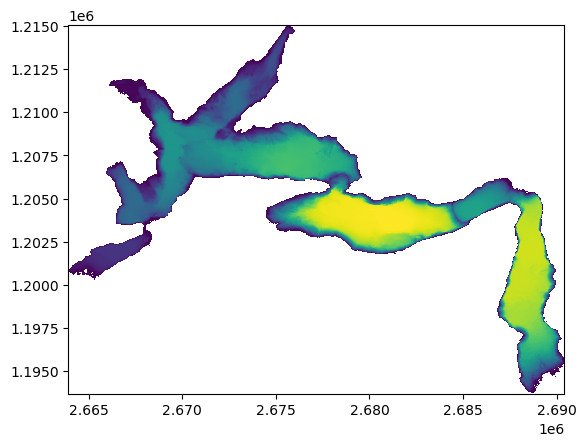

In [6]:
fig,ax = plt.subplots()
ax.pcolormesh(bathy.xsc,bathy.ysc,bathy.depth)
plt.plot()

In [170]:
xmin=2674300 
ymax=1206300 
newbathy= bathy.sel(xsc=slice(xmin,None),ysc=slice(None,ymax))

[]

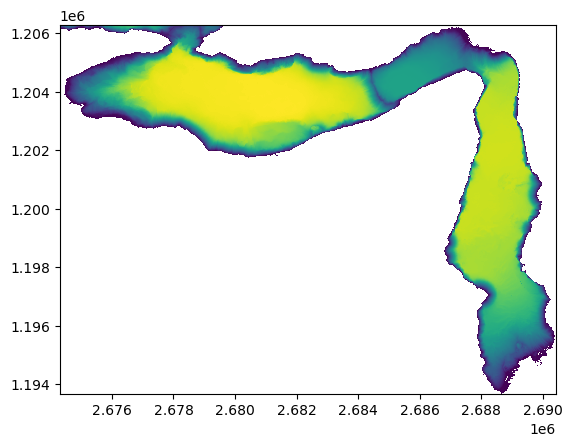

In [58]:
fig,ax = plt.subplots()
ax.pcolormesh(newbathy.xsc,newbathy.ysc,newbathy.depth)
plt.plot()

# CTD

In [171]:
fp='../data/CTD/sea&sun_2023_K3110853_1_L2.nc'
dsCTD=xr.open_dataset(fp)

In [172]:
dsCTD

<xarray.Dataset> Size: 560kB
Dimensions:     (depth: 4119)
Coordinates:
  * depth       (depth) float64 33kB 0.5101 0.5101 0.5137 ... 31.82 31.84 31.85
    time        (depth) datetime64[ns] 33kB ...
Data variables: (12/15)
    press       (depth) float64 33kB ...
    temp        (depth) float64 33kB ...
    cond        (depth) float64 33kB ...
    cond25      (depth) float64 33kB ...
    turb        (depth) float64 33kB ...
    do2_sat     (depth) float64 33kB ...
    ...          ...
    salin       (depth) float64 33kB ...
    cond20      (depth) float64 33kB ...
    rho         (depth) float64 33kB ...
    ptemp       (depth) float64 33kB ...
    prho        (depth) float64 33kB ...
    fall_speed  (depth) float64 33kB ...
Attributes: (12/22)
    project:        IBEX
    captain:        Stefan Hetkamp
    crew:           []
    lake:           Lucerne
    altitude:       436
    date:           2026-03-09
    ...             ...
    wind_strength:  
    drift:          
    boat_moving:    False
    stop:           []
    bottom:         False
    comments:

In [173]:
dsCTD.attrs

{'project': 'IBEX',
 'captain': 'Stefan Hetkamp',
 'crew': array([], dtype=float64),
 'lake': 'Lucerne',
 'altitude': np.int64(436),
 'date': '2026-03-09',
 'time': '08:30',
 'profile_loc': 'PA1',
 'xsc': np.int64(667000),
 'ysc': np.int64(202246),
 'lake_depth': np.float64(nan),
 'sensor': 'sea&sun',
 'serial_id': '2023',
 'tz_device_utc': np.int64(0),
 'tz_local_utc': np.int64(1),
 'wind_dir': '',
 'wind_strength': '',
 'drift': '',
 'boat_moving': 'False',
 'stop': array([], dtype=float64),
 'bottom': 'False',
 'comments': ''}

In [174]:
get_swiss_coords(dsCTD)

(np.int64(667000), np.int64(202246))

C:\Users\termesid\AppData\Local\Temp\ipykernel_14244\816995923.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap()


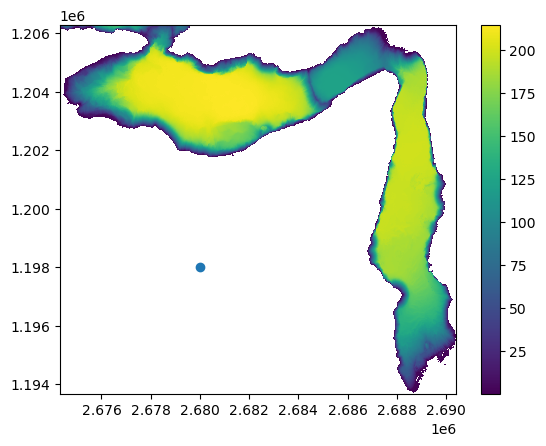

In [182]:
fig,ax = plt.subplots()
ax.pcolormesh(newbathy.xsc,newbathy.ysc,newbathy.depth)

cmap = cm.get_cmap()
norm = colors.Normalize(newbathy.depth.min().item(), newbathy.depth.max().item())

fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.plot(2.680e6,1.198e6,'o')
plt.show()

### Plot CTD profil Temp, density, Ox

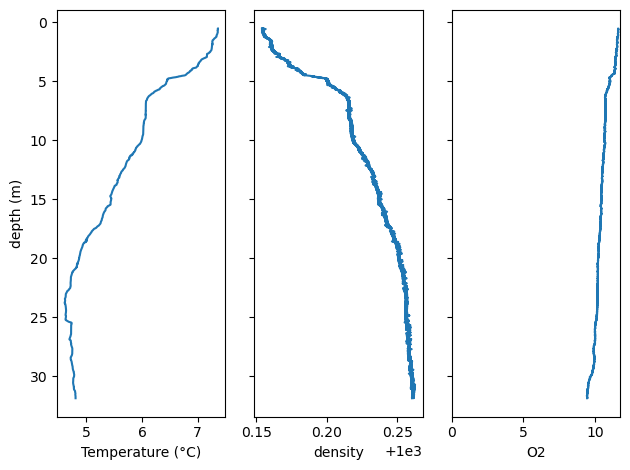

In [12]:

fig,ax=plt.subplots(1,3,sharey=True)
ax[0].plot(dsCTD.temp,dsCTD.depth)
ax[0].invert_yaxis()
ax[0].set_xlabel("Temperature (°C)")
ax[0].set_ylabel("depth (m)")

ax[1].plot(dsCTD.rho,dsCTD.depth)

ax[1].set_xlabel("density")


ax[2].plot(dsCTD.do2_conc,dsCTD.depth)
ax[2].set_xlim([0,None])
ax[2].set_xlabel("O2")

plt.tight_layout()
plt.show()

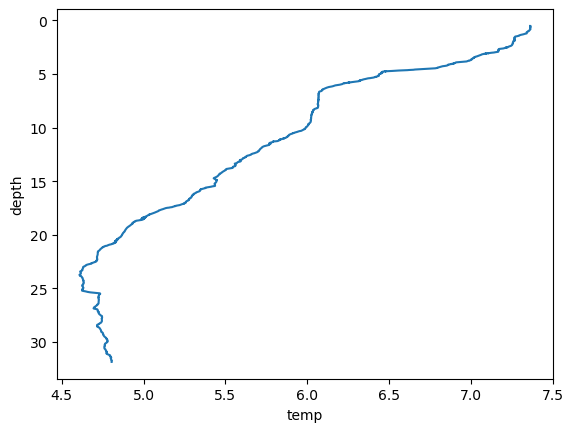

In [13]:
fig, ax = plt.subplots()

sns.lineplot(x=dsCTD.temp,y=dsCTD.depth,orient="y",ax=ax)
ax.invert_yaxis()
plt.show()


In [14]:
i=np.argmin(np.abs(dsCTD.depth-10).values)#temperature at 10m
dsCTD.temp[i]

<xarray.DataArray 'temp' ()> Size: 8B
array(5.9902)
Coordinates:
    time     datetime64[ns] 8B ...
    depth    float64 8B 10.0
Attributes:
    units:      °C
    long_name:  Temperature

# ADCP 

In [3]:
os.listdir('../data/adcp/')
fp='../data/adcp/MUO1_UP_03_23.nc'
adcp=xr.open_dataset(fp)

c:\Users\termesid\AppData\Local\anaconda3\envs\ewg\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
adcp

<xarray.Dataset> Size: 18MB
Dimensions:              (time: 13999, dir: 4, range: 40, beam: 4, x: 4, x*: 4,
                          earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 112kB 2023-03-31T06:00:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float64 320B 3.09 5.09 7.09 ... 79.09 81.09
  * beam                 (beam) int64 32B 1 2 3 4
  * x                    (x) int64 32B 1 2 3 4
  * x*                   (x*) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) uint32 56kB ...
    builtin_test_fail    (time) bool 14kB ...
    c_sound              (time) float32 56kB ...
    depth                (time) float32 56kB ...
    pitch                (time) float32 56kB ...
    roll                 (time) float32 56kB ...
    ...                   ...
    vel                  (dir, range, time) float32 9MB ...
    amp                  (beam, range, time) uint8 2MB ...
    corr                 (beam, range, time) uint8 2MB ...
    prcnt_gd             (beam, range, time) uint8 2MB ...
    beam2inst_orientmat  (x, x*) float64 128B ...
    orientmat            (earth, inst, time) float64 1MB ...
Attributes: (12/39)
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              vel
    has_imu:                  0
    prog_ver:                 51.42
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.24
    bandwidth:                0
    power_level:              255
    serialnum:                24399
    fs:                       0.0016680567139282735
    vel_gps_corrected:        0

In [5]:
adcp.attrs

{'inst_make': 'TRDI',
 'inst_type': 'ADCP',
 'rotate_vars': 'vel',
 'has_imu': np.int64(0),
 'prog_ver': np.float64(51.42),
 'inst_model': 'Workhorse',
 'beam_angle': np.int64(20),
 'freq': np.int64(600),
 'beam_pattern': 'convex',
 'orientation': 'up',
 'n_beams': np.int64(4),
 'n_cells': np.int64(40),
 'pings_per_ensemble': np.int64(110),
 'cell_size': np.float64(2.0),
 'blank_dist': np.float64(0.88),
 'profiling_mode': np.int64(1),
 'min_corr_threshold': np.int64(64),
 'n_code_reps': np.int64(9),
 'min_prcnt_gd': np.int64(0),
 'max_error_vel': np.float64(2.0),
 'sec_between_ping_groups': np.float64(5.45),
 'coord_sys': 'earth',
 'use_pitchroll': 'yes',
 'use_3beam': 'yes',
 'bin_mapping': 'yes',
 'heading_misalign_deg': np.float64(0.0),
 'magnetic_var_deg': np.float64(0.0),
 'sensors_src': '01111101',
 'sensors_avail': '00111101',
 'bin1_dist_m': np.float64(3.09),
 'transmit_pulse_m': np.float64(2.19),
 'water_ref_cells': array([1, 5]),
 'false_target_threshold': np.int64(50),
 'tra

x    velocity between 60 and 50 meters during may
for each day, max vel at 30 meters
x    range <=> depth correctly 
x    real time of adcp in water

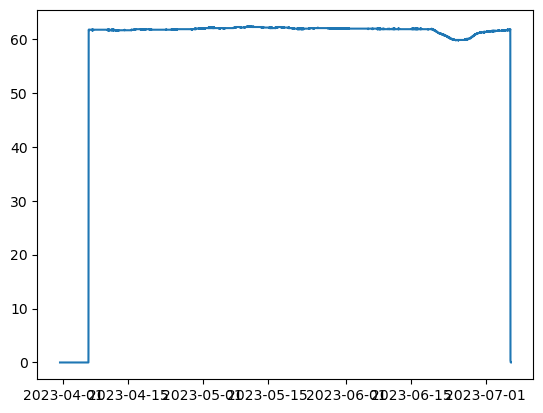

In [6]:
fig,ax=plt.subplots()

ax.plot(adcp.time,adcp.depth)

2023-04-06T09:50:00.000000000 2023-07-06T07:40:00.000000000
61.69154357910156


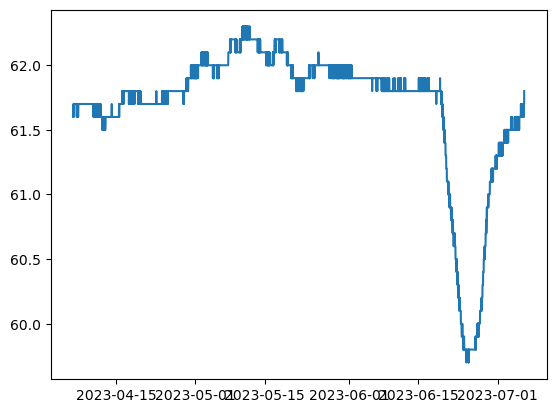

In [7]:
grad=adcp.depth.diff(dim='time')

fig,ax=plt.subplots()



i,j=np.argmax(grad.values),np.argmin(grad.values)

t_in,t_out=adcp.time.values[i+2],adcp.time.values[j-1]

ax.plot(adcp.time.sel(time=slice(t_in,t_out)),adcp.depth.sel(time=slice(t_in,t_out)))


print(t_in,t_out)
high=adcp.depth.isel(time=slice(i+2,j)).mean().item()
print(high)

In [8]:
realdepth=high-adcp.range.values
adcpcorr=adcp.assign_coords(realdepth=('range',realdepth))
adcpcorr=adcpcorr.where((adcpcorr.time >= t_in) & (adcpcorr.time <= t_out) , drop=True)
#adcpcorr=adcpcorr.where(adcpcorr.realdepth >= 0, drop=True)
adcpcorr

<xarray.Dataset> Size: 37MB
Dimensions:              (time: 13092, dir: 4, range: 40, beam: 4, x: 4, x*: 4,
                          earth: 3, inst: 3)
Coordinates:
  * time                 (time) datetime64[ns] 105kB 2023-04-06T09:50:00 ... ...
  * dir                  (dir) <U3 48B 'E' 'N' 'U' 'err'
  * range                (range) float64 320B 3.09 5.09 7.09 ... 79.09 81.09
    realdepth            (range) float64 320B 58.6 56.6 54.6 ... -17.4 -19.4
  * beam                 (beam) int64 32B 1 2 3 4
  * x                    (x) int64 32B 1 2 3 4
  * x*                   (x*) int64 32B 1 2 3 4
  * earth                (earth) <U1 12B 'E' 'N' 'U'
  * inst                 (inst) <U1 12B 'X' 'Y' 'Z'
Data variables: (12/21)
    number               (time) float64 105kB 888.0 889.0 ... 1.398e+04
    builtin_test_fail    (time) float64 105kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    c_sound              (time) float32 52kB 1.436e+03 1.436e+03 ... 1.433e+03
    depth                (time) float32 52kB 61.6 61.6 61.6 ... 61.7 61.7 61.8
    pitch                (time) float32 52kB -1.06 -1.06 -1.06 ... -1.17 -1.14
    roll                 (time) float32 52kB -1.0 -1.0 -0.98 ... -0.77 -0.81
    ...                   ...
    vel                  (dir, range, time) float32 8MB -0.01 -0.018 ... nan nan
    amp                  (beam, range, time) float32 8MB 126.0 116.0 ... 41.0
    corr                 (beam, range, time) float32 8MB 119.0 121.0 ... 9.0
    prcnt_gd             (beam, range, time) float32 8MB 0.0 0.0 0.0 ... 0.0 0.0
    beam2inst_orientmat  (x, x*, time) float64 2MB 1.462 1.462 ... -1.034 -1.034
    orientmat            (earth, inst, time) float64 943kB -0.7157 ... -0.9997
Attributes: (12/39)
    inst_make:                TRDI
    inst_type:                ADCP
    rotate_vars:              vel
    has_imu:                  0
    prog_ver:                 51.42
    inst_model:               Workhorse
    ...                       ...
    transmit_lag_m:           0.24
    bandwidth:                0
    power_level:              255
    serialnum:                24399
    fs:                       0.0016680567139282735
    vel_gps_corrected:        0

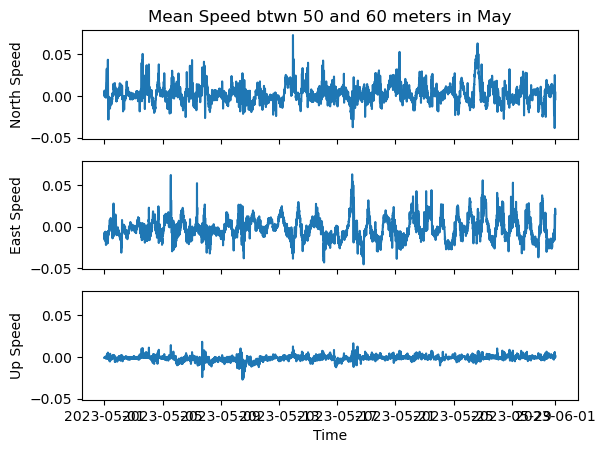

In [129]:
fig, ax = plt.subplots(3,1,sharex=True, sharey=True)

t=adcpcorr.time.sel(time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59'))
u=adcpcorr.vel.sel(realdepth=slice(60,50),dir='N', time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59')).mean(dim='range')
v=adcpcorr.vel.sel(realdepth=slice(60,50),dir='E',time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59')).mean(dim='range')
w=adcpcorr.vel.sel(realdepth=slice(60,50),dir='U',time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59')).mean(dim='range')

ax[0].plot(t,u)
ax[0].set_ylabel('North Speed')
ax[2].set_xlabel('Time')
ax[0].set_title('Mean Speed btwn 50 and 60 meters in May')

ax[1].plot(t,v)
ax[1].set_ylabel('East Speed')

ax[2].plot(t,w)
ax[2].set_ylabel('Up Speed')


plt.show()

Text(0.5, 1.0, 'Mean Speed btwn 50 and 60 meters in May')

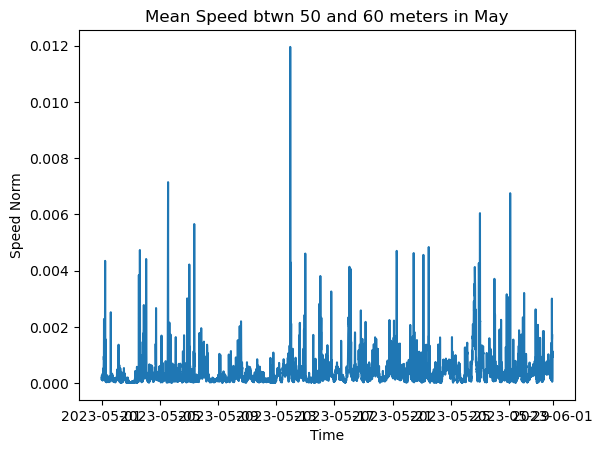

In [26]:
fig, ax = plt.subplots()

u=adcpcorr.vel.sel(realdepth=slice(60,50),dir='N', time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59'))
v=adcpcorr.vel.sel(realdepth=slice(60,50),dir='E',time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59'))
w=adcpcorr.vel.sel(realdepth=slice(60,50),dir='U',time=slice('2023-5-1 00:00:00','2023-5-31 23:59:59'))

N=(u*u+v*v+w*w).mean(dim='range')

ax.plot(t,N)
ax.set_ylabel('Speed Norm')
ax.set_xlabel('Time')
ax.set_title('Mean Speed btwn 50 and 60 meters in May')

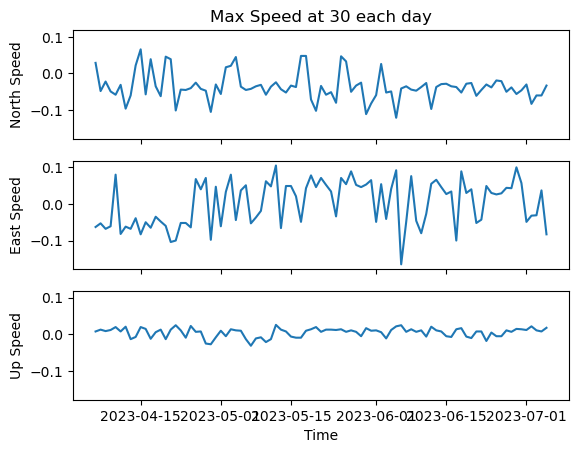

In [11]:
Days=np.arange(np.datetime64(t_in,'D'),np.datetime64(t_out,'D'),np.timedelta64(1,'D'))


maxvelu=np.zeros(len(Days))
maxvelv=np.zeros(len(Days))
maxvelw=np.zeros(len(Days))

for i in range(len(Days)):
    
    maxvelu[i]=max(adcpcorr.vel.sel(realdepth=30, method='nearest').sel(time=slice(Days[i], Days[i]+np.timedelta64(1,'D')), dir='N'),key=abs)
    maxvelv[i]=max(adcpcorr.vel.sel(realdepth=30, method='nearest').sel(time=slice(Days[i], Days[i]+np.timedelta64(1,'D')), dir='E'),key=abs)
    maxvelw[i]=max(adcpcorr.vel.sel(realdepth=30, method='nearest').sel(time=slice(Days[i], Days[i]+np.timedelta64(1,'D')), dir='U'),key=abs)


fig, ax = plt.subplots(3,1,sharex=True, sharey=True)

ax[0].plot(Days,maxvelu)
ax[0].set_ylabel('North Speed')
ax[2].set_xlabel('Time')
ax[0].set_title('Max Speed at 30 each day')

ax[1].plot(Days,maxvelv)
ax[1].set_ylabel('East Speed')

ax[2].plot(Days,maxvelw)
ax[2].set_ylabel('Up Speed')

plt.show()





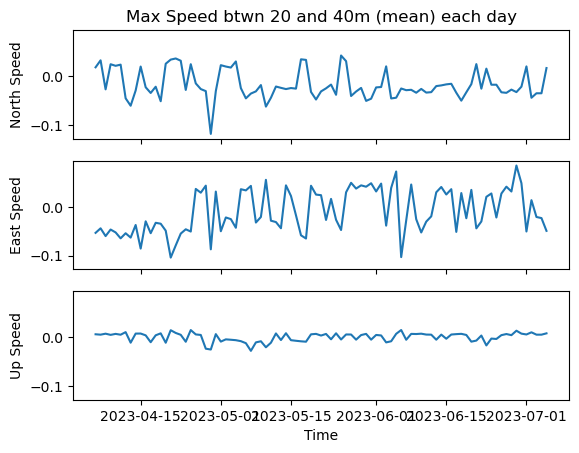

In [27]:
Days=np.arange(np.datetime64(t_in,'D'),np.datetime64(t_out,'D'),np.timedelta64(1,'D'))


maxvelu=np.zeros(len(Days))
maxvelv=np.zeros(len(Days))
maxvelw=np.zeros(len(Days))

for i in range(len(Days)):
    
    maxvelu[i]=max(adcpcorr.vel.sel(realdepth=slice(40,20)).sel(time=slice(Days[i], Days[i]+np.timedelta64(1,'D')), dir='N').mean(dim='range'),key=abs)
    maxvelv[i]=max(adcpcorr.vel.sel(realdepth=slice(40,20)).sel(time=slice(Days[i], Days[i]+np.timedelta64(1,'D')), dir='E').mean(dim='range'),key=abs)
    maxvelw[i]=max(adcpcorr.vel.sel(realdepth=slice(40,20)).sel(time=slice(Days[i], Days[i]+np.timedelta64(1,'D')), dir='U').mean(dim='range'),key=abs)


fig, ax = plt.subplots(3,1,sharex=True, sharey=True)

ax[0].plot(Days,maxvelu)
ax[0].set_ylabel('North Speed')
ax[2].set_xlabel('Time')
ax[0].set_title('Max Speed btwn 20 and 40m (mean) each day')

ax[1].plot(Days,maxvelv)
ax[1].set_ylabel('East Speed')

ax[2].plot(Days,maxvelw)
ax[2].set_ylabel('Up Speed')

plt.show()

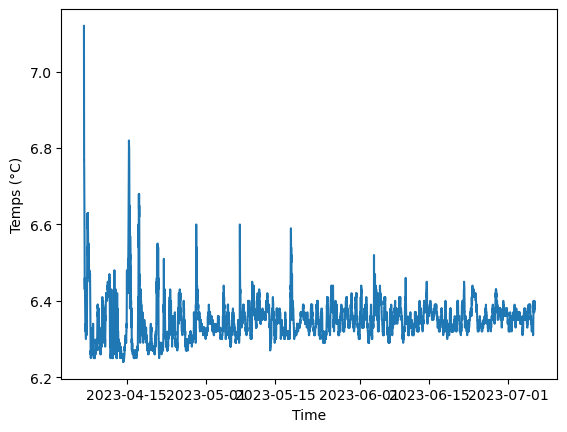

In [13]:
fig,ax=plt.subplots()

ax.plot(adcpcorr.time,adcpcorr.temp)
ax.set_ylabel('Temps (°C)')
ax.set_xlabel('Time')

plt.show()

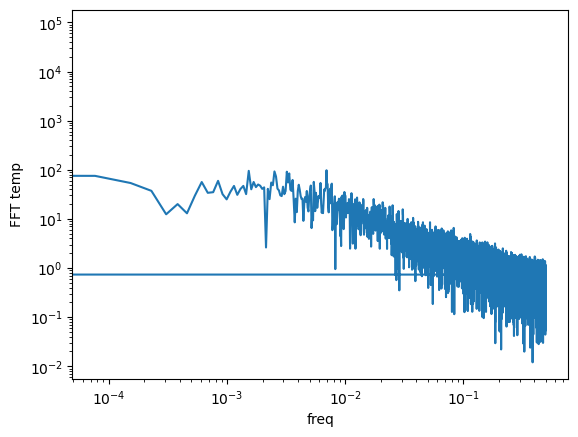

In [14]:
TF=np.fft.fft(adcpcorr.temp)
freq=np.fft.fftfreq(np.shape(adcpcorr.temp)[-1])

fig,ax=plt.subplots()

ax.loglog(freq,np.abs(TF))
ax.set_ylabel('FFT temp')
ax.set_xlabel('freq')
plt.show()


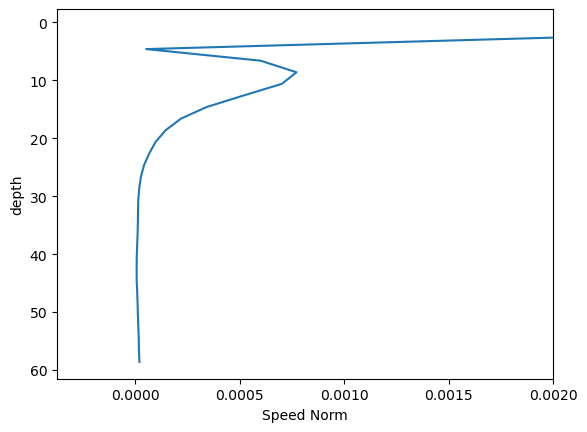

In [188]:
u=adcpcorr.vel.sel(dir='N',realdepth=slice(None,0)).mean(dim='time')
v=adcpcorr.vel.sel(dir='E',realdepth=slice(None,0)).mean(dim='time')
w=adcpcorr.vel.sel(dir='U',realdepth=slice(None,0)).mean(dim='time')

N=(u*u+v*v+w*w)

fig,ax=plt.subplots()
ax.plot(N,adcpcorr.realdepth.sel(realdepth=slice(None,0)))
ax.set_ylabel('depth')
ax.set_xlabel('Speed Norm')
ax.invert_yaxis()
ax.set_xlim(None,0.002)
plt.show()


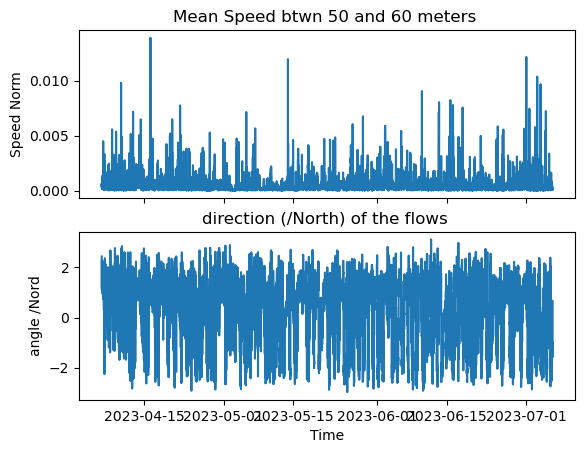

In [34]:
fig, ax = plt.subplots(2,1,sharex=True)

u=adcpcorr.vel.sel(realdepth=slice(60,50),dir='N')
v=adcpcorr.vel.sel(realdepth=slice(60,50),dir='E')
w=adcpcorr.vel.sel(realdepth=slice(60,50),dir='U')

N=(u*u+v*v+w*w).mean(dim='range')

dir=np.angle(u-v*1j).mean(axis=0)

ax[0].plot(adcpcorr.time,N)
ax[0].set_ylabel('Speed Norm')

ax[0].set_title('Mean Speed btwn 50 and 60 meters ')

ax[1].plot(adcpcorr.time,dir)
ax[1].set_ylabel('angle /Nord')
ax[1].set_xlabel('Time')
ax[1].set_title('direction (/North) of the flows ')


plt.show()

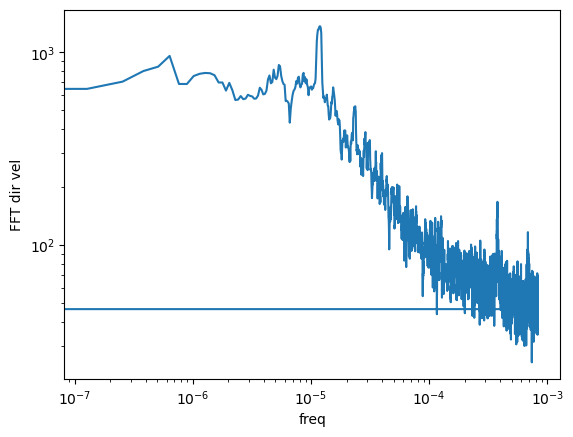

In [ ]:
dt=(adcpcorr.time.values[1]-adcpcorr.time.values[0])/np.timedelta64(1,'s')

TF=np.fft.fft(dir)
freq=np.fft.fftfreq(np.shape(dir)[-1],d=dt)

g = np.ones(10)/10
S = np.convolve(np.abs(TF),g,'same')

fig,ax=plt.subplots()

ax.loglog(freq,S)
ax.set_ylabel('FFT dir vel')
ax.set_xlabel('freq(s-1)')
plt.show()


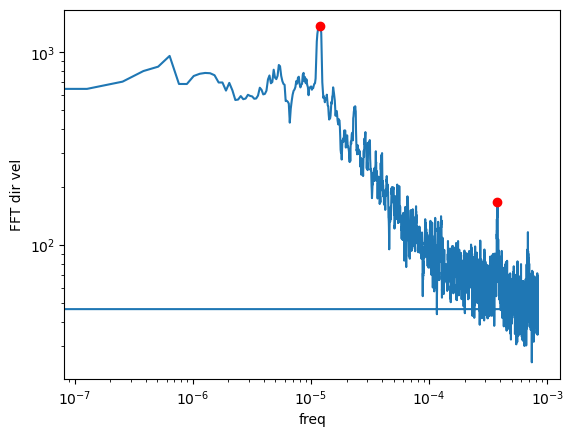

In [ ]:
P,_=sci.find_peaks(S,height=100,distance=2000,prominence=100)

fig,ax=plt.subplots()

ax.loglog(freq,S)
ax.loglog(freq[P],S[P],'o',color='red')
ax.set_ylabel('FFT dir vel')
ax.set_xlabel('freq(s-1)')
plt.show()

In [18]:
freq[P[0]],freq[P[1]]

(np.float64(1.1839291170180262e-05), np.float64(0.0003784754048273755))

In [19]:
(1/freq[P[1]])/(60)

np.float64(44.03632694248234)

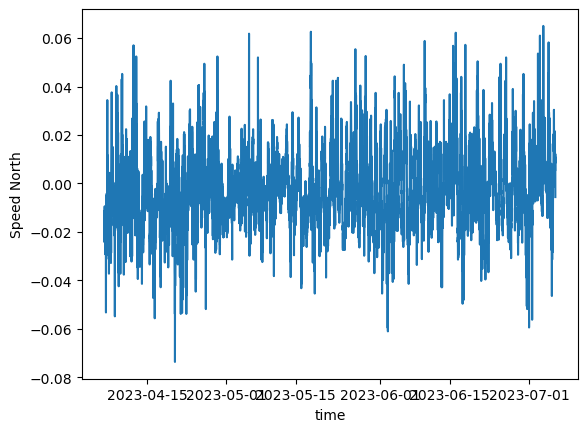

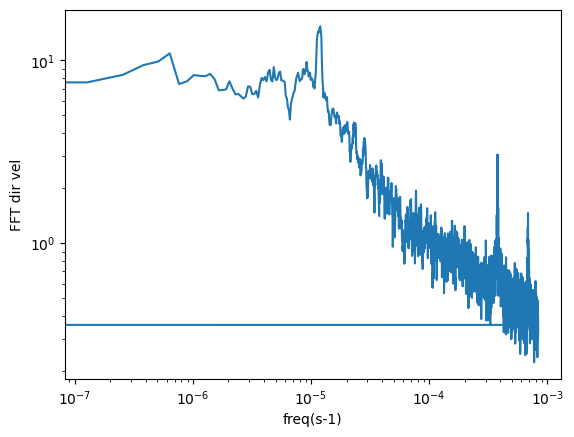

In [141]:
u=adcpcorr.vel.sel(realdepth=slice(60,50),dir='E').mean(dim='range')

fig,ax=plt.subplots()

ax.plot(adcpcorr.time,u)
ax.set_ylabel('Speed North')
ax.set_xlabel('time')

plt.show()

dt=(adcpcorr.time.values[1]-adcpcorr.time.values[0])/np.timedelta64(1,'s')

TF=np.fft.fft(u)
freq=np.fft.fftfreq(np.shape(u)[-1],d=dt)

g = np.ones(10)/10
S = np.convolve(np.abs(TF),g,'same')

fig,ax=plt.subplots()
ax.loglog(freq,S)
ax.set_ylabel('FFT dir vel')
ax.set_xlabel('freq(s-1)')
plt.show()

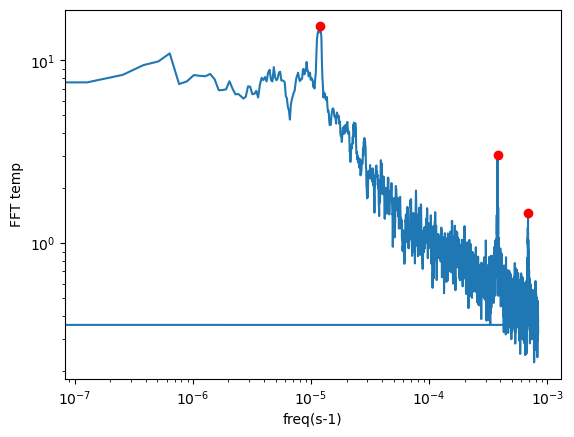

In [142]:
P,_=sci.find_peaks(S,height=0,distance=600,prominence=1)

fig,ax=plt.subplots()

ax.loglog(freq,S)
ax.loglog(freq[P],S[P],'o',color='red')
ax.set_ylabel('FFT temp')
ax.set_xlabel('freq(s-1)')
plt.show()

In [99]:
freq[P[0]],freq[P[1]]

(np.float64(6.365210306548528e-07), np.float64(3.055300947143293e-05))

In [146]:
(1/freq[P[1]])/(60*60)

np.float64(0.7341857335127862)